In [ ]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
sns.set(style="darkgrid")
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.metrics import balanced_accuracy_score,mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score,cross_val_predict

path= "/content/drive/MyDrive/Parkinsson disease.csv"
df = pd.read_csv(path)
df

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,phon_R01_S50_2,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,...,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,phon_R01_S50_3,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,...,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,phon_R01_S50_4,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,...,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,phon_R01_S50_5,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,...,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306


In [ ]:
df.rename(columns = {
                     'MDVP:Fo(Hz)': 'av_voc_hz',
                     'MDVP:Fhi(Hz)': 'max_voc_hz',
                     'MDVP:Flo(Hz)': 'min_voc_hz',
                     'MDVP:Jitter(%)': 'frq_percent',
                     'MDVP:Jitter(Abs)': 'frq_abs',
                     'MDVP:RAP': 'frq_rap',
                     'MDVP:PPQ': 'freq_ppq',
                     'Jitter:DDP': 'frq_ddp',
                     'MDVP:Shimmer': 'amp',
                     'MDVP:Shimmer(dB)': 'amp_db',
                     'Shimmer:APQ3': 'amp_apq3',
                     'Shimmer:APQ5': 'amp_apq5',
                     'MDVP:APQ': 'amp_apq',
                     'Shimmer:DDA': 'amp_dda',
                    },
          inplace = True)
df.head()

,name,av_voc_hz,max_voc_hz,min_voc_hz,frq_percent,frq_abs,frq_rap,freq_ppq,frq_ddp,amp,...,amp_dda,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [ ]:
df.drop('name', axis = 1, inplace = True)
df.head()

,av_voc_hz,max_voc_hz,min_voc_hz,frq_percent,frq_abs,frq_rap,freq_ppq,frq_ddp,amp,amp_db,...,amp_dda,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 23 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   av_voc_hz    195 non-null    float64
 1   max_voc_hz   195 non-null    float64
 2   min_voc_hz   195 non-null    float64
 3   frq_percent  195 non-null    float64
 4   frq_abs      195 non-null    float64
 5   frq_rap      195 non-null    float64
 6   freq_ppq     195 non-null    float64
 7   frq_ddp      195 non-null    float64
 8   amp          195 non-null    float64
 9   amp_db       195 non-null    float64
 10  amp_apq3     195 non-null    float64
 11  amp_apq5     195 non-null    float64
 12  amp_apq      195 non-null    float64
 13  amp_dda      195 non-null    float64
 14  NHR          195 non-null    float64
 15  HNR          195 non-null    float64
 16  status       195 non-null    int64  
 17  RPDE         195 non-null    float64
 18  DFA          195 non-null    float64
 19  spread1 

*No Null Value Detected*

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.describe()

,av_voc_hz,max_voc_hz,min_voc_hz,frq_percent,frq_abs,frq_rap,freq_ppq,frq_ddp,amp,amp_db,...,amp_dda,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


<Axes: >

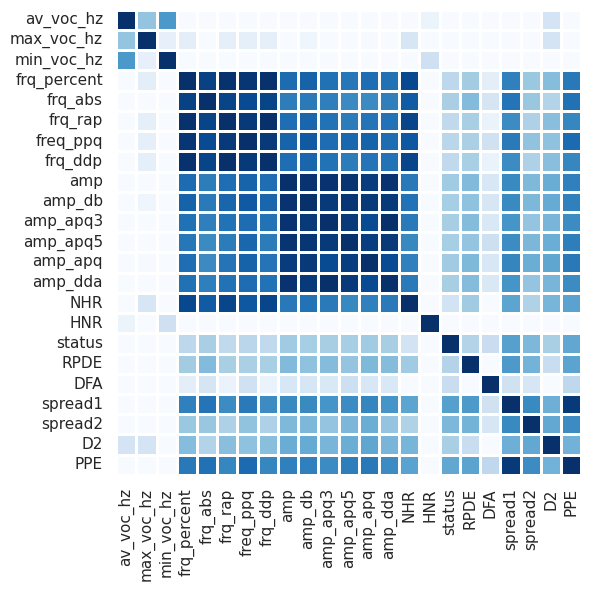

In [ ]:
cor = df.corr()
plt.figure(figsize = (6,8))
sns.heatmap(cor, cbar=0, linewidths=2,vmax=1, vmin=0, square=True, cmap='Blues')

**Splitting Data**

In [ ]:
X = df.drop(['status'], axis=1).values
y = df['status'].values

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.30, random_state=0) #101


**Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:

logReg = LogisticRegression()
logReg.fit(X_train,y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
LogisticRegression()

LogisticRegression()

In [ ]:
predict = logReg.predict(X_test)
predict

array([1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1])

In [ ]:
logReg.score(X_test, y_test)

0.9152542372881356

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test, predict))

              precision    recall  f1-score   support

           0       0.90      0.69      0.78        13
           1       0.92      0.98      0.95        46

    accuracy                           0.92        59
   macro avg       0.91      0.84      0.86        59
weighted avg       0.91      0.92      0.91        59



**Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
X_scaled = scaler.fit_transform(df.drop(["status"], axis=1).values)

In [ ]:
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(X_scaled,y, test_size=0.30, random_state=0) #101

**Model Predict through confusion metrix**

In [ ]:
def model_performance(model,xs_train = X_train_scaled,xs_test = X_test_scaled, ys_train = y_train_scaled,ys_test = y_test_scaled):
    print(f"{model} Performance:\n")
    y_train_pred = cross_val_predict(model,xs_train,ys_train,cv=4)
    plt.figure(figsize = (5,5))
    sns.heatmap(confusion_matrix(ys_train,y_train_pred),annot = True)
    plt.title('Confusion Matrix')
    plt.show()
    print('Precision Score:',precision_score(ys_train,y_train_pred))
    print("Recall Score:",recall_score(ys_train,y_train_pred))
    print("Accuracy Score:",accuracy_score(ys_train,y_train_pred))
    print("Cross Val Score Insample",cross_val_score(model,xs_train,ys_train,cv=4,scoring='accuracy').mean())
    print("Cross Val Score Outsample",cross_val_score(model,xs_test,ys_test,cv=4,scoring='accuracy').mean())

**KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
error_rate = []

In [ ]:
for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled,y_train_scaled)
    pred_i = knn.predict(X_test_scaled)
    error_rate.append(np.mean(pred_i != y_test_scaled))

In [ ]:

error_rate

[0.06779661016949153,
 0.13559322033898305,
 0.06779661016949153,
 0.1016949152542373,
 0.06779661016949153,
 0.0847457627118644,
 0.0847457627118644,
 0.1016949152542373,
 0.1016949152542373,
 0.1016949152542373,
 0.11864406779661017,
 0.13559322033898305,
 0.13559322033898305,
 0.13559322033898305,
 0.15254237288135594,
 0.15254237288135594,
 0.15254237288135594,
 0.15254237288135594,
 0.13559322033898305,
 0.13559322033898305,
 0.15254237288135594,
 0.15254237288135594,
 0.13559322033898305,
 0.11864406779661017,
 0.11864406779661017,
 0.11864406779661017,
 0.15254237288135594,
 0.15254237288135594,
 0.2033898305084746,
 0.1864406779661017,
 0.1864406779661017,
 0.13559322033898305,
 0.1694915254237288,
 0.1694915254237288,
 0.1864406779661017,
 0.1694915254237288,
 0.1864406779661017,
 0.1864406779661017,
 0.1864406779661017]

Text(0, 0.5, 'Error Rate')

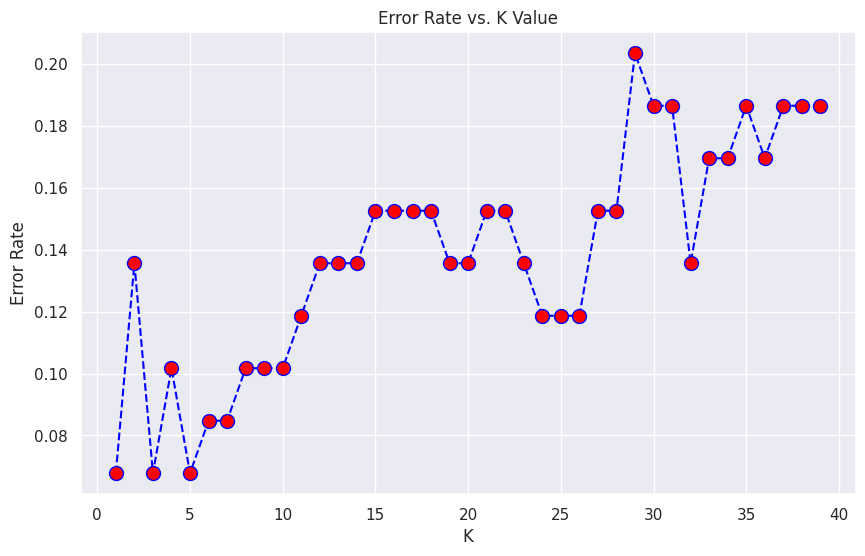

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(range(1,40),error_rate,color='blue', linestyle='dashed', marker='o',markerfacecolor='red', markersize=10)

plt.title('Error Rate vs. K Value')

plt.xlabel('K')

plt.ylabel('Error Rate')


In [ ]:
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train_scaled, y_train_scaled)

KNeighborsClassifier(n_neighbors=1)

In [ ]:

pred = knn.predict(X_test_scaled)

In [ ]:
pred

array([1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

In [ ]:
knn.score(X_test_scaled, y_test_scaled)

0.9322033898305084

In [ ]:
print(classification_report(y_test_scaled, pred))

              precision    recall  f1-score   support

           0       0.76      1.00      0.87        13
           1       1.00      0.91      0.95        46

    accuracy                           0.93        59
   macro avg       0.88      0.96      0.91        59
weighted avg       0.95      0.93      0.94        59



KNeighborsClassifier(n_neighbors=1) Performance:



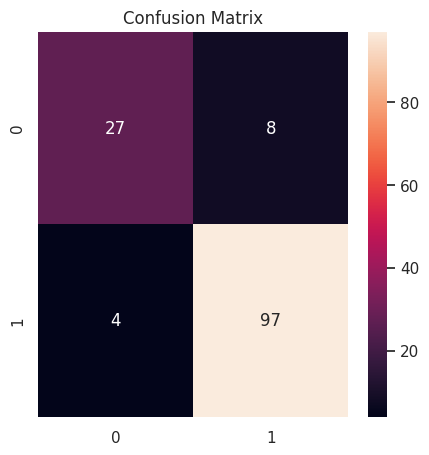

Precision Score: 0.9238095238095239
Recall Score: 0.9603960396039604
Accuracy Score: 0.9117647058823529
Cross Val Score Insample 0.9117647058823529
Cross Val Score Outsample 0.8821428571428571


In [ ]:
model_performance(knn)

**SVC**

In [ ]:
from sklearn.svm import SVC

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
svc=SVC() #only in default parameters, I got the highest score)

In [ ]:
svc.fit(X_train_scaled,y_train_scaled)

SVC()

In [ ]:
y_pred=svc.predict(X_test_scaled)

In [ ]:
print('Model accuracy score with default hyperparameters : {0:0.4f}'. format(accuracy_score(y_test_scaled, y_pred)))

Model accuracy score with default hyperparameters : 0.9322


In [ ]:
print(classification_report(y_test_scaled, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.69      0.82        13
           1       0.92      1.00      0.96        46

    accuracy                           0.93        59
   macro avg       0.96      0.85      0.89        59
weighted avg       0.94      0.93      0.93        59



SVC & KNN have the same accuracy level.

**Decission Tree Classifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
DCT = DecisionTreeClassifier(max_depth = 8,min_samples_split = 2,max_leaf_nodes = 9)
DCT.fit(X_train_scaled,y_train_scaled)

DecisionTreeClassifier(max_depth=8, max_leaf_nodes=9)

In [ ]:
dct_pred = DCT.predict(X_test_scaled)

In [ ]:
print(classification_report(y_test_scaled, dct_pred))

              precision    recall  f1-score   support

           0       0.72      1.00      0.84        13
           1       1.00      0.89      0.94        46

    accuracy                           0.92        59
   macro avg       0.86      0.95      0.89        59
weighted avg       0.94      0.92      0.92        59



In [ ]:
DCT.score(X_test_scaled, y_test_scaled)

0.9152542372881356

DecisionTreeClassifier(max_depth=8, max_leaf_nodes=9) Performance:



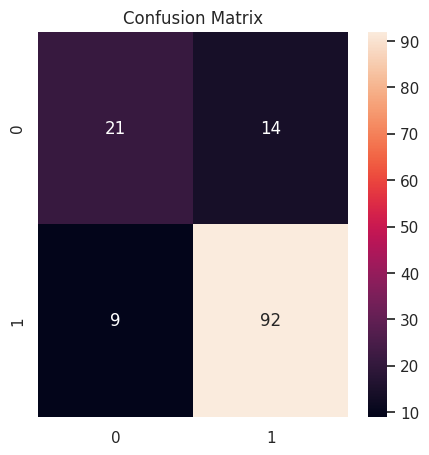

Precision Score: 0.8679245283018868
Recall Score: 0.9108910891089109
Accuracy Score: 0.8308823529411765
Cross Val Score Insample 0.8235294117647058
Cross Val Score Outsample 0.898809523809524


In [ ]:
model_performance(DCT)

**Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rfc1 = RandomForestClassifier(max_depth = 8,n_estimators = 260, criterion = 'gini')
rfc1.fit(X_train_scaled,y_train_scaled)

RandomForestClassifier(max_depth=8, n_estimators=260)

In [ ]:
rfc1.score(X_test_scaled, y_test_scaled)

0.9661016949152542

RandomForestClassifier(max_depth=8, n_estimators=260) Performance:



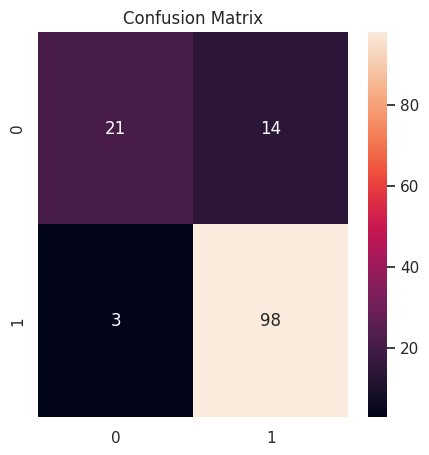

Precision Score: 0.875
Recall Score: 0.9702970297029703
Accuracy Score: 0.875
Cross Val Score Insample 0.8529411764705882
Cross Val Score Outsample 0.8976190476190476


In [ ]:
model_performance(rfc1)

In [ ]:
rfc_pred = rfc1.predict(X_test_scaled)

In [ ]:
print(classification_report(y_test_scaled, rfc_pred))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        13
           1       0.98      0.98      0.98        46

    accuracy                           0.97        59
   macro avg       0.95      0.95      0.95        59
weighted avg       0.97      0.97      0.97        59

